In [9]:
import numpy as np
import math
import matplotlib.pyplot as plt
import pandas as pd

def init_peg_positions(n=4):
    peg_positions = np.zeros((n, 3), dtype=float)

    for i in range(n):
        x_pos = i * math.cos(math.radians(23.5)) * 0.3321
        z_pos = math.sin(math.radians(23.5)) * (
            math.cos(math.pi * i / 2) ** 2) * 0.3321

        peg_positions[i] = [x_pos, 0.0, z_pos]

    return peg_positions

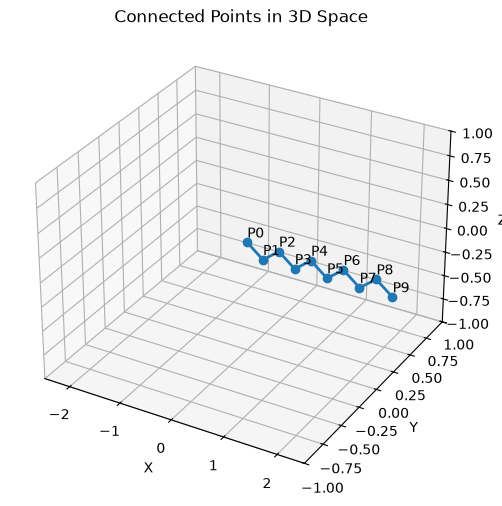

In [10]:
points = init_peg_positions(10)

fig = plt.figure(figsize=(7, 6))
ax = fig.add_subplot(111, projection="3d")

# Plot points and connect consecutive points with lines
ax.plot(
    points[:, 0],
    points[:, 1],
    points[:, 2],
    marker="o",
    linewidth=2
)

# Label each point
for i, (x, y, z) in enumerate(points):
    ax.text(x, y, z + 0.05, f"P{i}", fontsize=10)

ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")
ax.set_title("Connected Points in 3D Space")

# Give the y and z axes visible ranges despite all values being zero
ax.set_xlim(-2.5, 2.5)
ax.set_ylim(-1, 1)
ax.set_zlim(-1, 1)

plt.show()

In [11]:
df_l = pd.read_csv("peg_bond_length.csv")
df_ba = pd.read_csv("peg_bond_angle.csv")
df_l.loc[df_l.iloc[:, 1].idxmin()]
df_ba.loc[df_ba.iloc[:, 1].idxmin()]

Bond angle (degrees)    132.9
Potentials (kJ/mol)       0.0
Name: 1329, dtype: float64

In [12]:
bond_length = df_l.to_numpy().T
bond_angle = pd.read_csv("peg_bond_angle.csv").to_numpy().T
dihedral_angle = pd.read_csv("peg_dihedral_angle.csv").to_numpy().T
dihedral_angle[0] = np.deg2rad(dihedral_angle[0])
bond_angle[0] = np.deg2rad(bond_angle[0])

In [13]:
# Setting up the PEG simulation
import hoomd
import gsd.hoomd

frame = gsd.hoomd.Frame()

# Place a polymer in the box.
frame.particles.mass = [44.0] * 10
frame.particles.N = 10
frame.particles.position = init_peg_positions(10)
frame.particles.types = ["A"]
frame.particles.typeid = [0] * 10
frame.configuration.box = [20, 20, 20, 0, 0, 0]

# Connect particles with bonds.
frame.bonds.N = 9
frame.bonds.types = ["A-A"]
frame.bonds.typeid = [0] * 9
frame.bonds.group = [[0, 1], [1, 2], [2, 3], [3, 4],
                     [4, 5], [5, 6], [6, 7], [7, 8], [8, 9]]
# Initialise frame angles
frame.angles.N = 8
frame.angles.types = ["A-A-A"]
frame.angles.typeid = [0] * 8
frame.angles.group = [[0, 1, 2], [1, 2, 3], [2, 3, 4], [3, 4, 5],
                     [4, 5, 6], [5, 6, 7], [6, 7, 8], [7, 8, 9]]

# Initialise dihedral angles
frame.dihedrals.N = 7
frame.dihedrals.types = ["A-A-A-A"]
frame.dihedrals.typeid = [0] * 7
frame.dihedrals.group = [[0, 1, 2, 3], [1, 2, 3, 4], [2, 3, 4, 5], [3, 4, 5, 6],
                     [4, 5, 6, 7], [5, 6, 7, 8], [6, 7, 8, 9]]


with gsd.hoomd.open(name="peg_simulation.gsd", mode="w") as f:
    f.append(frame)

# Apply the potential on the bonds.
bonds = hoomd.md.bond.Table(bond_length.shape[1])
bonds.params["A-A"] = dict(r_min = bond_length[0][0], r_max = bond_length[0][-1],
                           U = bond_length[1], F = -np.gradient(bond_length[1], bond_length[0]))
# Apply bond angles
angles = hoomd.md.angle.Table(bond_angle.shape[1])
angles.params["A-A-A"] = dict(U = bond_angle[1], tau = -np.gradient(bond_angle[1], bond_angle[0]))

# Apply dihedral angles
dihedrals = hoomd.md.dihedral.Table(dihedral_angle.shape[1])
dihedrals.params["A-A-A-A"] = dict(U = dihedral_angle[1], tau = -np.gradient(dihedral_angle[1], dihedral_angle[0]))

# Perform the MD simulation.
sim = hoomd.Simulation(device=hoomd.device.CPU(), seed=1)
sim.create_state_from_gsd(filename="peg_simulation.gsd")
langevin = hoomd.md.methods.Langevin(filter=hoomd.filter.All(), kT=1.0)
integrator = hoomd.md.Integrator(dt=0.005, methods=[langevin], forces=[bonds, angles, dihedrals])
gsd_writer = hoomd.write.GSD(
    filename="molecular_trajectory.gsd", trigger=hoomd.trigger.Periodic(10), mode="wb"
)
sim.operations.integrator = integrator
sim.operations.writers.append(gsd_writer)

sim.run(10000, write_at_start=True)

# Ensure buffered frames are physically written
gsd_writer.flush()

traj = gsd.hoomd.open(
    name="molecular_trajectory.gsd",
    mode="r"
)

print("Number of frames:", len(traj))

Number of frames: 1001


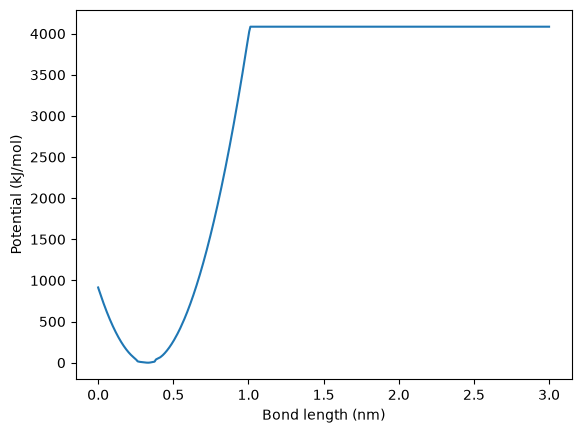

In [14]:
fig, ax = plt.subplots()

ax.plot(bond_length[0], bond_length[1])

ax.set_xlabel("Bond length (nm)")
ax.set_ylabel("Potential (kJ/mol)")

plt.show()

In [15]:
bond_length[0][0]

np.float64(0.0)

In [16]:
bond_length[0][-1]

np.float64(3.0)

In [17]:
# This is not intended as a full tutorial on fresnel - see the fresnel user
# documentation (https://fresnel.readthedocs.io/) if you would like to learn more.

import warnings
import os
import fresnel
import IPython
import packaging.version
import PIL
import io

device = fresnel.Device()
tracer = fresnel.tracer.Path(device=device, w=300, h=300)

FRESNEL_MIN_VERSION = packaging.version.parse("0.13.0")
FRESNEL_MAX_VERSION = packaging.version.parse("0.14.0")


def render(snapshot):
    if (
        "version" not in dir(fresnel)
        or packaging.version.parse(fresnel.version.version) < FRESNEL_MIN_VERSION
        or packaging.version.parse(fresnel.version.version) >= FRESNEL_MAX_VERSION
    ):
        warnings.warn(
            f"Unsupported fresnel version {fresnel.version.version} - expect errors."
        )
    L = snapshot.configuration.box[0]
    scene = fresnel.Scene(device)
    geometry = fresnel.geometry.Sphere(
        scene, N=len(snapshot.particles.position), radius=0.3
    )
    geometry.material = fresnel.material.Material(
        color=fresnel.color.linear([252 / 255, 209 / 255, 1 / 255]), roughness=0.5
    )
    geometry.position[:] = snapshot.particles.position[:]
    geometry.outline_width = 0.04
    fresnel.geometry.Box(scene, [L, L, L, 0, 0, 0], box_radius=0.02)

    scene.lights = [
        fresnel.light.Light(direction=(0, 0, 1), color=(0.8, 0.8, 0.8), theta=math.pi),
        fresnel.light.Light(
            direction=(1, 1, 1), color=(1.1, 1.1, 1.1), theta=math.pi / 3
        ),
    ]
    scene.camera = fresnel.camera.Orthographic(
        position=(L * 2, L, L * 2), look_at=(0, 0, 0), up=(0, 1, 0), height=L * 0.8 + 1
    )
    scene.background_alpha = 1
    scene.background_color = (1, 1, 1)
    samples = 2000
    if "CI" in os.environ:
        samples = 100
    return IPython.display.Image(tracer.sample(scene, samples=samples)._repr_png_())

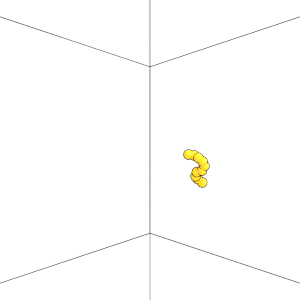

In [18]:
render(sim.state.get_snapshot())

In [19]:
# Rendering a 3D movie

device = fresnel.Device()
tracer = fresnel.tracer.Path(device=device, w=300, h=300)

FRESNEL_MIN_VERSION = packaging.version.parse("0.13.0")
FRESNEL_MAX_VERSION = packaging.version.parse("0.14.0")


def render_movie(trajectory, duration=100):
    if len(trajectory) == 0:
        raise ValueError("Trajectory contains no frames.")

    rendered_frames = []

    for frame in trajectory:
        rendered = render(frame)

        # render() returns an IPython.display.Image
        image = PIL.Image.open(
            io.BytesIO(rendered.data)
        ).convert("RGB")

        rendered_frames.append(image)

    gif_buffer = io.BytesIO()

    rendered_frames[0].save(
        gif_buffer,
        format="GIF",
        save_all=True,
        append_images=rendered_frames[1:],
        duration=duration,
        loop=0
    )

    return IPython.display.display(
        IPython.display.Image(data=gif_buffer.getvalue())
    )

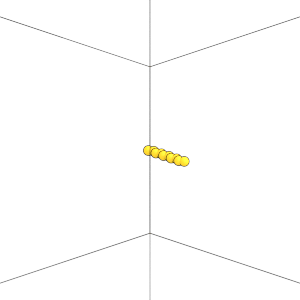

In [20]:
render_movie(traj[::30], duration = 100)

In [42]:
-np.gradient(bond_length[1], bond_length[0])

array([ 1.17200000e+04,  8.84833333e+03,  5.49833333e+03, ...,
        9.31322575e-10, -9.31322575e-10, -0.00000000e+00], shape=(10001,))